In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/3rd-wear-dataset-challenge-hasca-2026/sample_submission.csv
/kaggle/input/competitions/3rd-wear-dataset-challenge-hasca-2026/participant_meta_data.txt
/kaggle/input/competitions/3rd-wear-dataset-challenge-hasca-2026/test/test_inertial_data.npy
/kaggle/input/competitions/3rd-wear-dataset-challenge-hasca-2026/test/test_meta_data.csv
/kaggle/input/competitions/3rd-wear-dataset-challenge-hasca-2026/test/test_videomae_data.npy
/kaggle/input/competitions/3rd-wear-dataset-challenge-hasca-2026/train/inertial_feat/sbj_13.csv
/kaggle/input/competitions/3rd-wear-dataset-challenge-hasca-2026/train/inertial_feat/sbj_17.csv
/kaggle/input/competitions/3rd-wear-dataset-challenge-hasca-2026/train/inertial_feat/sbj_15.csv
/kaggle/input/competitions/3rd-wear-dataset-challenge-hasca-2026/train/inertial_feat/sbj_16.csv
/kaggle/input/competitions/3rd-wear-dataset-challenge-hasca-2026/train/inertial_feat/sbj_19.csv
/kaggle/input/competitions/3rd-wear-dataset-challenge-hasca-2026/tr

# WEAR: Multimodal Activity Recognition. 

* ***The objective is to classify human physical activities into 19 different classes using inertial sensor data, and later improve the model by incorporating egocentric video features.***
  
  
**“The inertial sensors provide 3-axis acceleration data from different body locations such as the right arm, right leg, left leg, and left arm. The data is sampled at 50 Hz.”**

**“I divided the continuous sensor data into 1-second windows containing 50 samples, with a 50% overlap, so the stride is 25 samples.”**

**“Initially, I focused only on the inertial data. I developed several experiments, where each experiment addressed a limitation observed in the previous model.”**

#**EDA — What we examined**

Dataset structure

Training inertial data is stored as subject/file CSVs.

There are 24 inertial files.

There are 24 corresponding VideoMAE files.

Inertial data

Inertial sampling rate: 50 Hz.

We work with 3-axis acceleration for each sensor location.

Sensor locations:
right_arm
right_leg
left_leg
left_arm

Activity labels
The problem has 19 activity classes, including null.
We converted the activity names into numerical class IDs for model training.
Windowing
We use a 1-second window = 50 inertial samples.
We use 50% overlap, so the stride is 25 samples.
This converts continuous sensor streams into individual activity examples.
Missing/invalid values
We checked for problematic sensor values.
The preprocessing handled NaN/infinite values using forward fill, backward fill and zero filling where needed.
Sensor values were clipped to a reasonable range before training.
VideoMAE alignment
Video is sampled at 30 FPS.
Inertial data is 50 Hz.
Therefore:
50 inertial samples = 1 second
30 video frames     = 1 second
With 50% overlap:
25 inertial samples → 15 video frames
Alignment validation

We didn't just assume that the modalities were aligned. We explicitly checked:

Sampling ratio       → PASS
Video feature size   → 768 → PASS
Window counts        → PASS
Window mapping       → PASS
Window duration      → PASS
50% stride           → PASS



“Before building the models, I performed exploratory data analysis to understand the structure of the WEAR dataset. I examined the number of subjects and files, the sensor locations, sampling frequency, activity labels and the distribution of the sensor data. I also checked for missing and invalid sensor values.”


“Because the data is a continuous time series, I converted it into 1-second windows. Since the inertial signal is sampled at 50 Hz, each window contains 50 samples, and I used a stride of 25 samples, giving 50% overlap.”

“Since the project later uses both inertial and egocentric video information, I also performed an alignment validation between the two modalities. The inertial data is sampled at 50 Hz and the VideoMAE features correspond to 30 FPS. Therefore, one 1-second inertial window corresponds to 30 video frames. I verified this mapping across all 24 subject/file pairs, and all the alignment checks passed.”



In [2]:
# ==============================
# CELL 1: Imports and Config
# ==============================


import torch
from torch.utils.data import Dataset

# Paths
TRAIN_DIR = "/kaggle/input/competitions/3rd-wear-dataset-challenge-hasca-2026/train/inertial_feat"

TEST_INERTIAL_PATH = "/kaggle/input/competitions/3rd-wear-dataset-challenge-hasca-2026/test/test_inertial_data.npy"

TEST_META_PATH = "/kaggle/input/competitions/3rd-wear-dataset-challenge-hasca-2026/test/test_meta_data.csv"

SAMPLE_SUB_PATH = "/kaggle/input/competitions/3rd-wear-dataset-challenge-hasca-2026/sample_submission.csv"

OUT_DIR = "/kaggle/working"

# Window settings
WINDOW_SIZE = 50
STRIDE = 25

print("Setup complete!")

Setup complete!


In [3]:

import torch
from torch.utils.data import Dataset

# -----------------------------
# Settings
# -----------------------------
WINDOW_SIZE = 50
STRIDE = 25

LOCATIONS = ["right_arm", "right_leg", "left_leg", "left_arm"]

LABEL_MAP = {
    "null": 0,
    "jogging": 1,
    "jogging (rotating arms)": 2,
    "jogging (skipping)": 3,
    "jogging (sidesteps)": 4,
    "jogging (butt-kicks)": 5,
    "stretching (triceps)": 6,
    "stretching (lunging)": 7,
    "stretching (shoulders)": 8,
    "stretching (hamstrings)": 9,
    "stretching (lumbar rotation)": 10,
    "push-ups": 11,
    "push-ups (complex)": 12,
    "sit-ups": 13,
    "sit-ups (complex)": 14,
    "burpees": 15,
    "lunges": 16,
    "lunges (complex)": 17,
    "bench-dips": 18
}

LOCATION_MAP = {
    "right_arm": 0,
    "right_leg": 1,
    "left_leg": 2,
    "left_arm": 3
}


# -----------------------------
# Sensor columns
# -----------------------------
SENSOR_COLUMNS = {
    loc: [f"{loc}_acc_{axis}" for axis in ["x", "y", "z"]]
    for loc in LOCATIONS
}


# -----------------------------
# Load and clean CSV
# -----------------------------
def load_data(file):
    df = pd.read_csv(file)

    # Missing labels
    df["label"] = df["label"].fillna("null")

    # Convert labels to numbers
    df["label_id"] = df["label"].map(LABEL_MAP)

    # Sensor columns
    sensor_cols = sum(SENSOR_COLUMNS.values(), [])

    # Replace infinity and missing values
    df[sensor_cols] = (
        df[sensor_cols]
        .replace([np.inf, -np.inf], np.nan)
        .ffill()
        .bfill()
        .fillna(0)
    )

    # Limit extreme values
    df[sensor_cols] = df[sensor_cols].clip(-20, 20)

    return df


# -----------------------------
# Create windows
# -----------------------------
def create_windows(df, file_name):

    samples = []

    for start in range(0, len(df) - WINDOW_SIZE + 1, STRIDE):

        end = start + WINDOW_SIZE

        # Most common label in the window
        label = df["label_id"].iloc[start:end].mode()[0]

        for location in LOCATIONS:

            columns = SENSOR_COLUMNS[location]

            x = df[columns].iloc[start:end].values.astype(np.float32)

            samples.append({
                "x": x,
                "y": int(label),
                "location": location,
                "sbj_id": int(df["sbj_id"].iloc[0]),
                "sbj_file": file_name,
                "start_idx": start
            })

    return samples


# -----------------------------
# Build complete dataset
# -----------------------------
def build_dataset(data_folder):

    all_samples = []

    for file in sorted(os.listdir(data_folder)):

        if not file.endswith(".csv"):
            continue

        path = os.path.join(data_folder, file)

        df = load_data(path)

        samples = create_windows(
            df,
            file.replace(".csv", "")
        )

        all_samples.extend(samples)

        print(
            file,
            "->",
            len(samples),
            "samples"
        )

    return all_samples


# -----------------------------
# PyTorch Dataset
# -----------------------------
class WEARDataset(Dataset):

    def __init__(self, samples, mean=None, std=None):

        self.samples = samples
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):

        sample = self.samples[index]

        x = sample["x"]

        # Normalization
        if self.mean is not None:
            x = (x - self.mean) / self.std

        # (50, 3) -> (3, 50)
        x = torch.tensor(x.T, dtype=torch.float32)

        y = torch.tensor(
            sample["y"],
            dtype=torch.long
        )

        location = torch.tensor(
            LOCATION_MAP[sample["location"]],
            dtype=torch.long
        )

        return x, y, location


# -----------------------------
# Calculate mean and std
# -----------------------------
def get_normalization(samples):

    data = np.concatenate(
        [s["x"] for s in samples],
        axis=0
    )

    mean = data.mean(axis=0)
    std = data.std(axis=0) + 1e-8

    return mean, std


# -----------------------------
# Load test data
# -----------------------------
def load_test_data(inertial_file, metadata_file):

    x = np.load(inertial_file).astype(np.float32)
    meta = pd.read_csv(metadata_file)

    return x, meta


class WEARTestDataset(Dataset):

    def __init__(self, x, meta, mean=None, std=None):

        self.x = x
        self.meta = meta.reset_index(drop=True)

        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.x)

    def __getitem__(self, index):

        x = self.x[index]

        if self.mean is not None:
            x = (x - self.mean) / self.std

        x = torch.tensor(
            x.T,
            dtype=torch.float32
        )

        # Find sensor location column
        if "sensor_location" in self.meta.columns:
            location = self.meta.loc[index, "sensor_location"]
        else:
            location = self.meta.loc[index, "inertial_sensor_location"]

        location = torch.tensor(
            LOCATION_MAP[location],
            dtype=torch.long
        )

        sample_id = int(
            self.meta.loc[index, "id"]
        )

        return x, location, sample_id

In [4]:
samples = build_dataset(TRAIN_DIR)

print("Total samples:", len(samples))

sbj_0.csv -> 22352 samples
sbj_0_2.csv -> 17924 samples
sbj_1.csv -> 22220 samples


/tmp/ipykernel_58/659226459.py:58: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


sbj_10.csv -> 31876 samples
sbj_11.csv -> 17772 samples
sbj_12.csv -> 26156 samples
sbj_13.csv -> 31820 samples
sbj_14.csv -> 25604 samples
sbj_14_2.csv -> 26836 samples
sbj_15.csv -> 20820 samples
sbj_16.csv -> 28076 samples
sbj_17.csv -> 24724 samples
sbj_18.csv -> 21052 samples
sbj_19.csv -> 16868 samples
sbj_2.csv -> 28508 samples
sbj_20.csv -> 15260 samples
sbj_21.csv -> 20444 samples
sbj_3.csv -> 33364 samples
sbj_4.csv -> 25528 samples
sbj_5.csv -> 17200 samples
sbj_6.csv -> 20024 samples
sbj_7.csv -> 22820 samples
sbj_8.csv -> 19956 samples
sbj_9.csv -> 17324 samples
Total samples: 554528


In [5]:
mean, std = get_normalization(samples)

print("Mean:", mean)
print("Std:", std)

Mean: [ 0.34622332  0.19935441 -0.03861388]
Std: [0.8844678 0.72252   0.5065534]


In [6]:
train_dataset = WEARDataset(samples, mean, std)

print("Dataset size:", len(train_dataset))

Dataset size: 554528


In [7]:
test_x, test_meta = load_test_data(
    TEST_INERTIAL_PATH,
    TEST_META_PATH
)

print("Test shape:", test_x.shape)
print("Test metadata shape:", test_meta.shape)

Test shape: (12234, 50, 3)
Test metadata shape: (12234, 3)


In [8]:
print(os.listdir(TRAIN_DIR)[:5])

train_file = os.path.join(TRAIN_DIR, os.listdir(TRAIN_DIR)[0])
df = pd.read_csv(train_file)

print(df.shape)
print(df.columns.tolist())
print(df.head())

['sbj_13.csv', 'sbj_17.csv', 'sbj_15.csv', 'sbj_16.csv', 'sbj_19.csv']
(198900, 14)
['sbj_id', 'right_arm_acc_x', 'right_arm_acc_y', 'right_arm_acc_z', 'right_leg_acc_x', 'right_leg_acc_y', 'right_leg_acc_z', 'left_leg_acc_x', 'left_leg_acc_y', 'left_leg_acc_z', 'left_arm_acc_x', 'left_arm_acc_y', 'left_arm_acc_z', 'label']
   sbj_id  right_arm_acc_x  right_arm_acc_y  right_arm_acc_z  right_leg_acc_x  \
0      13         0.985410         0.427802        -0.220678         0.993032   
1      13         1.023319         0.407526        -0.205827         0.995623   
2      13         1.055614         0.381112        -0.210316         0.993614   
3      13         1.053501         0.362515        -0.205788         0.987870   
4      13         1.063559         0.344431        -0.193696         0.982861   

   right_leg_acc_y  right_leg_acc_z  left_leg_acc_x  left_leg_acc_y  \
0        -0.051425         0.127800        0.994454       -0.008355   
1        -0.042938         0.124939        0.

In [9]:
# ==============================
# CELL 3: Model
# ==============================

import torch
import torch.nn as nn


class ConvBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=5,
            stride=stride,
            padding=2
        )

        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size=5,
            padding=2
        )

        self.bn2 = nn.BatchNorm1d(out_channels)

        # Shortcut when number of channels changes
        # or when the size is reduced
        if in_channels != out_channels or stride != 1:
            self.shortcut = nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size=1,
                stride=stride
            )
        else:
            self.shortcut = nn.Identity()

        self.relu = nn.ReLU()


    def forward(self, x):

        identity = self.shortcut(x)

        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))

        x = x + identity

        return self.relu(x)


class WEARInertialNet(nn.Module):

    def __init__(
        self,
        num_classes=19,
        num_locations=4
    ):
        super().__init__()

        # CNN layers
        self.conv1 = nn.Conv1d(
            3, 32,
            kernel_size=7,
            padding=3
        )

        self.bn1 = nn.BatchNorm1d(32)

        self.block1 = ConvBlock(32, 32)

        self.block2 = ConvBlock(
            32, 64,
            stride=2
        )

        self.block3 = ConvBlock(
            64, 128,
            stride=2
        )

        # Convert sequence to one feature vector
        self.pool = nn.AdaptiveAvgPool1d(1)

        # Sensor-location information
        self.location_embedding = nn.Embedding(
            num_locations,
            8
        )

        # Final classifier
        self.fc = nn.Sequential(
            nn.Linear(128 + 8, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )


    def forward(self, x, location):

        # CNN
        x = self.conv1(x)
        x = self.relu(self.bn1(x)) if hasattr(self, "relu") else torch.relu(self.bn1(x))

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        # Pool
        x = self.pool(x)
        x = x.squeeze(-1)

        # Location embedding
        location = self.location_embedding(location)

        # Combine sensor features + location
        x = torch.cat([x, location], dim=1)

        # Classification
        return self.fc(x)


# Create model
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = WEARInertialNet().to(device)

print(model)
print("\nDevice:", device)

WEARInertialNet(
  (conv1): Conv1d(3, 32, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (block1): ConvBlock(
    (conv1): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Identity()
    (relu): ReLU()
  )
  (block2): ConvBlock(
    (conv1): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Conv1d(32, 64, kernel_size=(1,), stride=(2,))
    (relu)

In [10]:

# ============================================================
# EDA — PART 1
# DATASET OVERVIEW
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("WEAR DATASET — EXPLORATORY DATA ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

if "samples" not in globals():
    raise RuntimeError(
        "❌ 'samples' was not found.\n"
        "Please run your dataset-building cells first."
    )

print("✅ Samples found:", len(samples))

# ------------------------------------------------------------
# Convert sample information to DataFrame
# ------------------------------------------------------------

eda_df = pd.DataFrame({
    "label_id": [s["y"] for s in samples],
    "location": [s["location"] for s in samples],
    "sbj_id": [s["sbj_id"] for s in samples],
    "sbj_file": [s["sbj_file"] for s in samples],
    "start_idx": [s["start_idx"] for s in samples]
})

# Label names
LABEL_NAMES = {
    0: "null",
    1: "jogging",
    2: "jogging (rotating arms)",
    3: "jogging (skipping)",
    4: "jogging (sidesteps)",
    5: "jogging (butt-kicks)",
    6: "stretching (triceps)",
    7: "stretching (lunging)",
    8: "stretching (shoulders)",
    9: "stretching (hamstrings)",
    10: "stretching (lumbar rotation)",
    11: "push-ups",
    12: "push-ups (complex)",
    13: "sit-ups",
    14: "sit-ups (complex)",
    15: "burpees",
    16: "lunges",
    17: "lunges (complex)",
    18: "bench-dips"
}

eda_df["activity"] = eda_df["label_id"].map(LABEL_NAMES)

print()
print("Dataset shape:", eda_df.shape)

print()
print("Columns:")
print(eda_df.columns.tolist())

print()
print("First 5 samples:")
display(eda_df.head())

print()
print("Unique participants:",
      eda_df["sbj_id"].nunique())

print(
    "Unique recording files:",
    eda_df["sbj_file"].nunique()
)

print(
    "Sensor locations:",
    eda_df["location"].nunique()
)

print(
    "Activities:",
    eda_df["activity"].nunique()
)

WEAR DATASET — EXPLORATORY DATA ANALYSIS
✅ Samples found: 554528

Dataset shape: (554528, 6)

Columns:
['label_id', 'location', 'sbj_id', 'sbj_file', 'start_idx', 'activity']

First 5 samples:


,label_id,location,sbj_id,sbj_file,start_idx,activity
0,0,right_arm,0,sbj_0,0,null
1,0,right_leg,0,sbj_0,0,null
2,0,left_leg,0,sbj_0,0,null
3,0,left_arm,0,sbj_0,0,null
4,1,right_arm,0,sbj_0,25,jogging



Unique participants: 22
Unique recording files: 24
Sensor locations: 4
Activities: 19


ACTIVITY DISTRIBUTION


,label_id,activity,samples
0,0,null,220456
1,1,jogging,20024
2,2,jogging (rotating arms),17536
3,3,jogging (skipping),18212
4,4,jogging (sidesteps),19732
5,5,jogging (butt-kicks),17224
6,6,stretching (triceps),18636
7,7,stretching (lunging),19524
8,8,stretching (shoulders),18052
9,9,stretching (hamstrings),18412


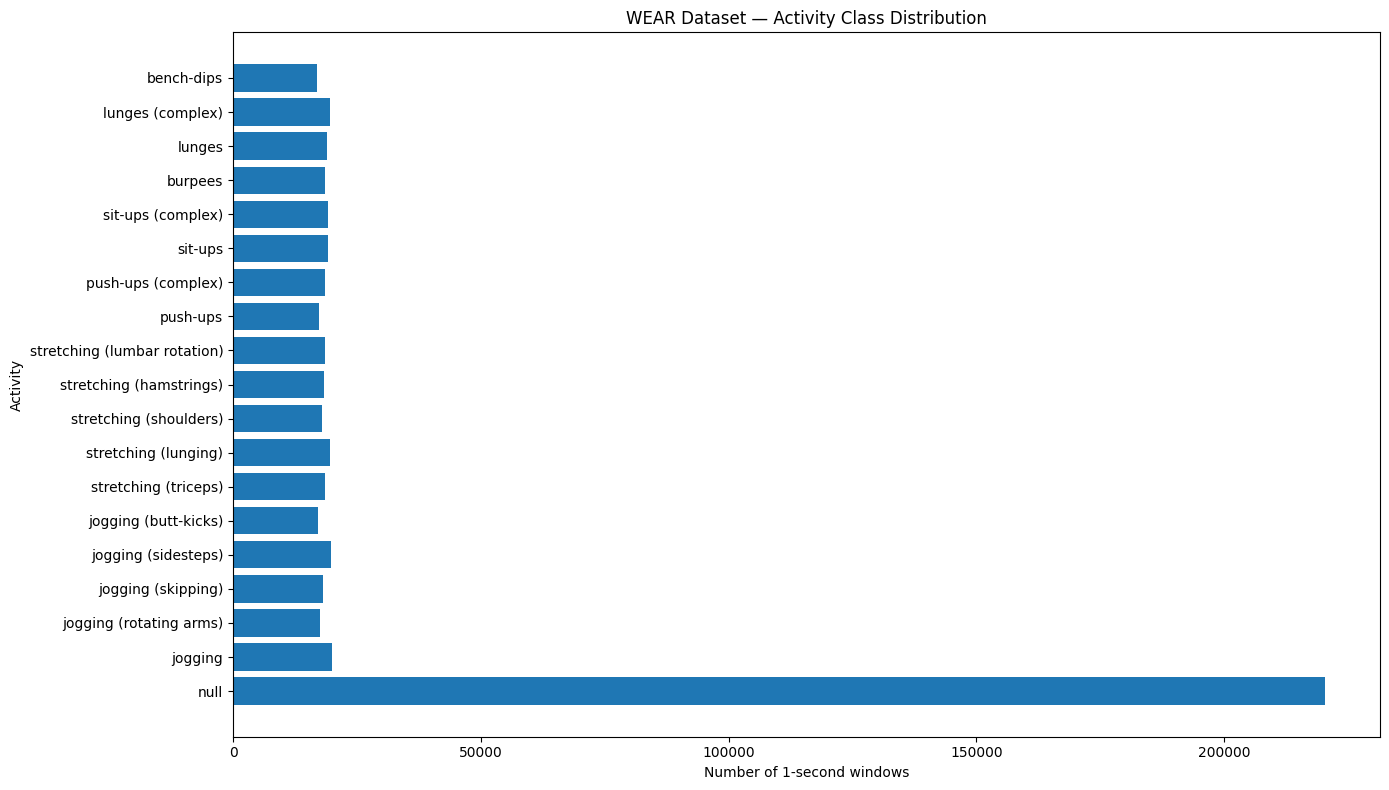

In [11]:
# ============================================================
# EDA — ACTIVITY / CLASS DISTRIBUTION
# ============================================================

activity_counts = (
    eda_df
    .groupby(["label_id", "activity"])
    .size()
    .reset_index(name="samples")
    .sort_values("label_id")
)

print("=" * 70)
print("ACTIVITY DISTRIBUTION")
print("=" * 70)

display(activity_counts)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(14, 8))

plt.barh(
    activity_counts["activity"],
    activity_counts["samples"]
)

plt.xlabel("Number of 1-second windows")
plt.ylabel("Activity")
plt.title(
    "WEAR Dataset — Activity Class Distribution"
)

plt.tight_layout()

plt.show()

ACTIVITY DISTRIBUTION — PERCENTAGE


,label_id,activity,samples,percentage
0,0,null,220456,39.76
1,1,jogging,20024,3.61
2,2,jogging (rotating arms),17536,3.16
3,3,jogging (skipping),18212,3.28
4,4,jogging (sidesteps),19732,3.56
5,5,jogging (butt-kicks),17224,3.11
6,6,stretching (triceps),18636,3.36
7,7,stretching (lunging),19524,3.52
8,8,stretching (shoulders),18052,3.26
9,9,stretching (hamstrings),18412,3.32


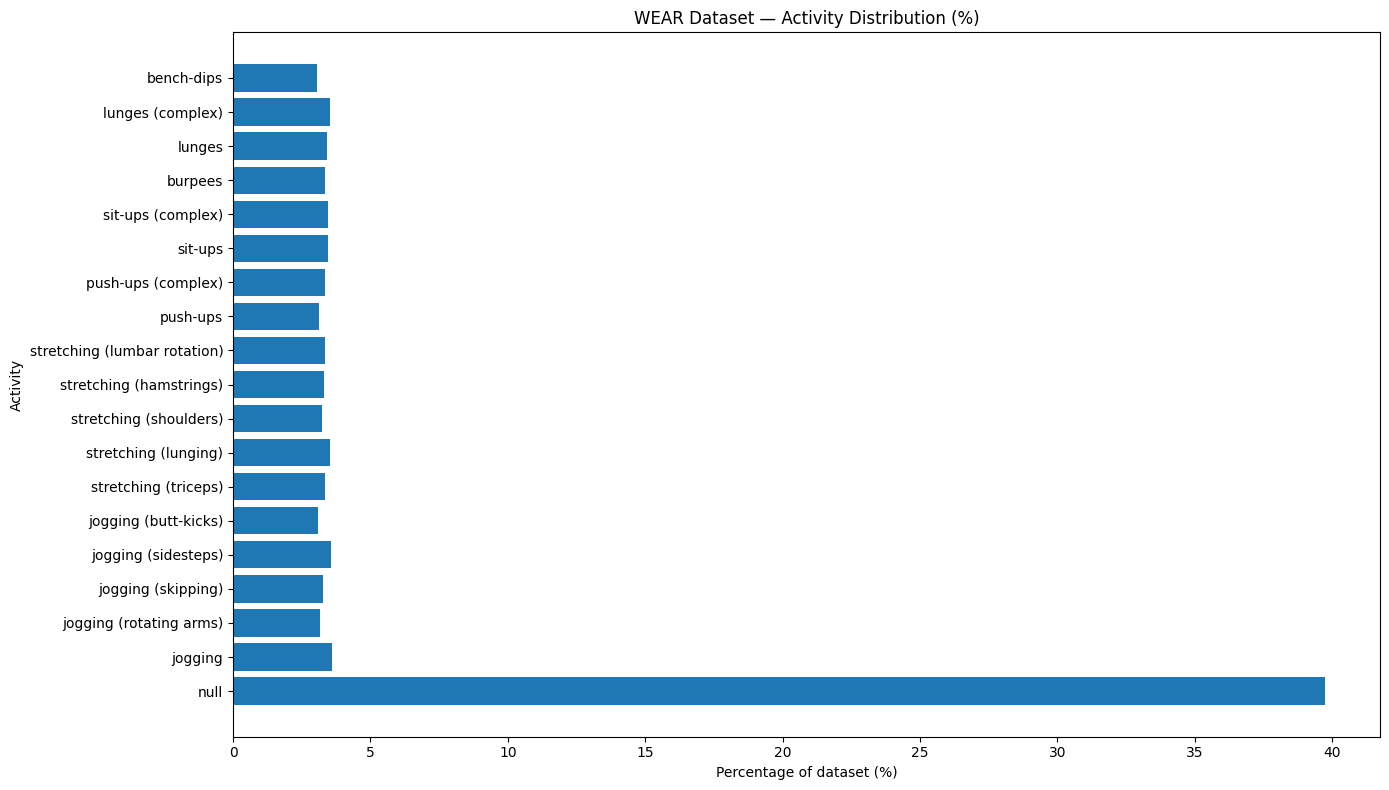

In [12]:
# ============================================================
# EDA — CLASS DISTRIBUTION (%)
# ============================================================

activity_counts["percentage"] = (
    activity_counts["samples"]
    / activity_counts["samples"].sum()
    * 100
)

print("=" * 70)
print("ACTIVITY DISTRIBUTION — PERCENTAGE")
print("=" * 70)

display(
    activity_counts[
        ["label_id", "activity", "samples", "percentage"]
    ].round(2)
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(14, 8))

plt.barh(
    activity_counts["activity"],
    activity_counts["percentage"]
)

plt.xlabel("Percentage of dataset (%)")
plt.ylabel("Activity")
plt.title(
    "WEAR Dataset — Activity Distribution (%)"
)

plt.tight_layout()

plt.show()

SENSOR LOCATION DISTRIBUTION


,samples
location,
right_arm,138632
right_leg,138632
left_leg,138632
left_arm,138632


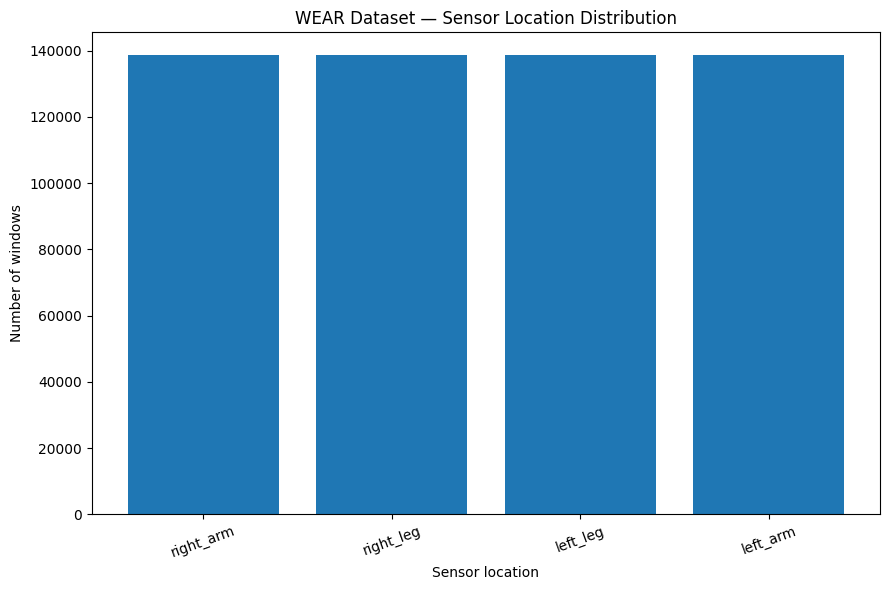

In [13]:
# ============================================================
# EDA — SENSOR LOCATION DISTRIBUTION
# ============================================================

location_counts = (
    eda_df["location"]
    .value_counts()
    .reindex(LOCATIONS)
)

print("=" * 70)
print("SENSOR LOCATION DISTRIBUTION")
print("=" * 70)

display(
    location_counts
    .rename("samples")
    .to_frame()
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.bar(
    location_counts.index,
    location_counts.values
)

plt.xlabel("Sensor location")
plt.ylabel("Number of windows")
plt.title(
    "WEAR Dataset — Sensor Location Distribution"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

ACTIVITY × SENSOR LOCATION


location,right_arm,right_leg,left_leg,left_arm
activity,,,,
null,55114,55114,55114,55114
jogging,5006,5006,5006,5006
jogging (rotating arms),4384,4384,4384,4384
jogging (skipping),4553,4553,4553,4553
jogging (sidesteps),4933,4933,4933,4933
jogging (butt-kicks),4306,4306,4306,4306
stretching (triceps),4659,4659,4659,4659
stretching (lunging),4881,4881,4881,4881
stretching (shoulders),4513,4513,4513,4513


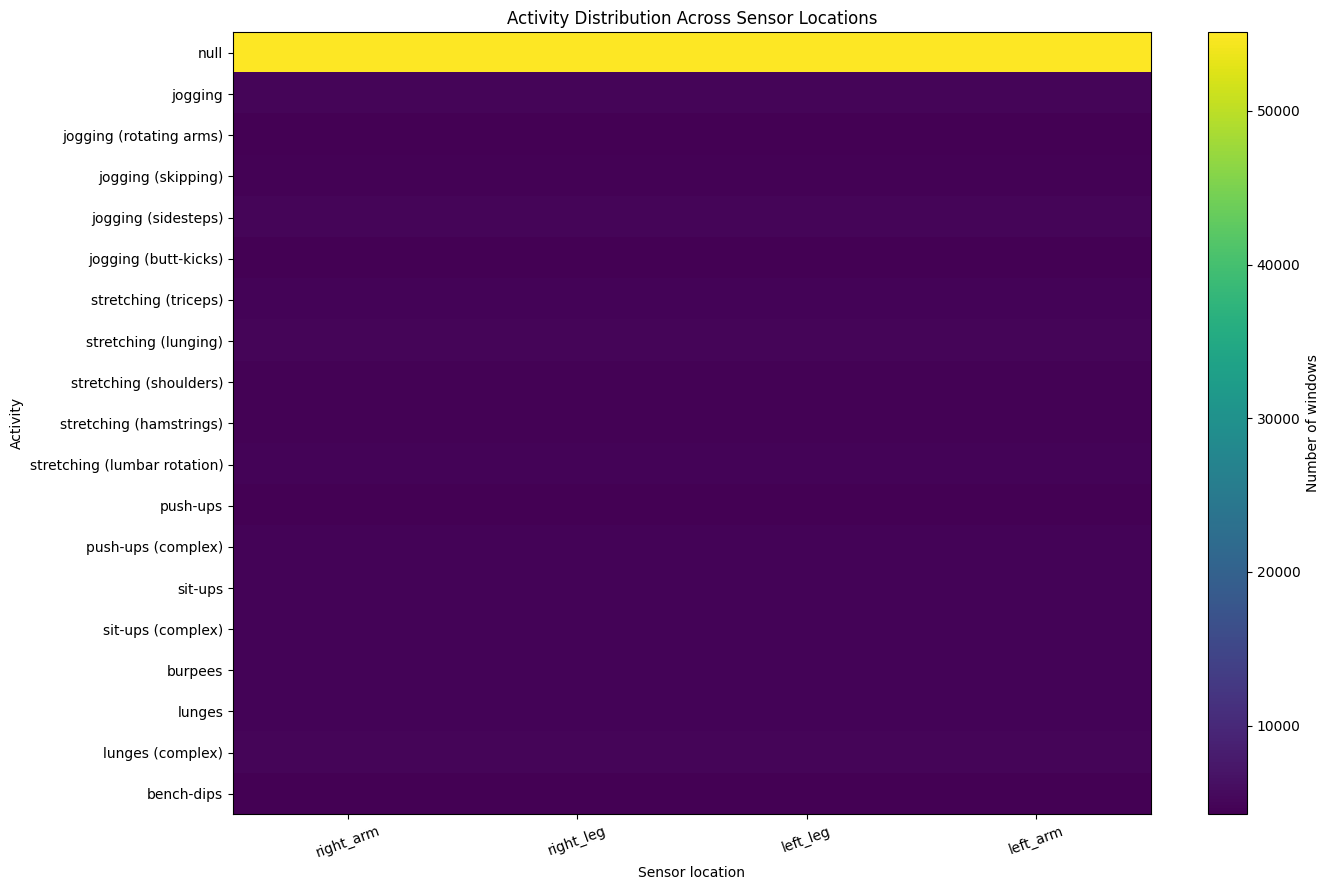

In [14]:
# ============================================================
# EDA — ACTIVITY × SENSOR LOCATION
# ============================================================

activity_location = pd.crosstab(
    eda_df["activity"],
    eda_df["location"]
)

activity_location = activity_location.reindex(
    LABEL_NAMES.values()
)

activity_location = activity_location[
    LOCATIONS
]

print("=" * 70)
print("ACTIVITY × SENSOR LOCATION")
print("=" * 70)

display(activity_location)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(14, 9))

plt.imshow(
    activity_location.values,
    aspect="auto"
)

plt.colorbar(
    label="Number of windows"
)

plt.xticks(
    range(len(LOCATIONS)),
    LOCATIONS,
    rotation=20
)

plt.yticks(
    range(len(activity_location)),
    activity_location.index
)

plt.xlabel("Sensor location")
plt.ylabel("Activity")

plt.title(
    "Activity Distribution Across Sensor Locations"
)

plt.tight_layout()

plt.show()

PARTICIPANT DISTRIBUTION


,samples
sbj_id,
0,40276
1,22220
2,28508
3,33364
4,25528
5,17200
6,20024
7,22820
8,19956


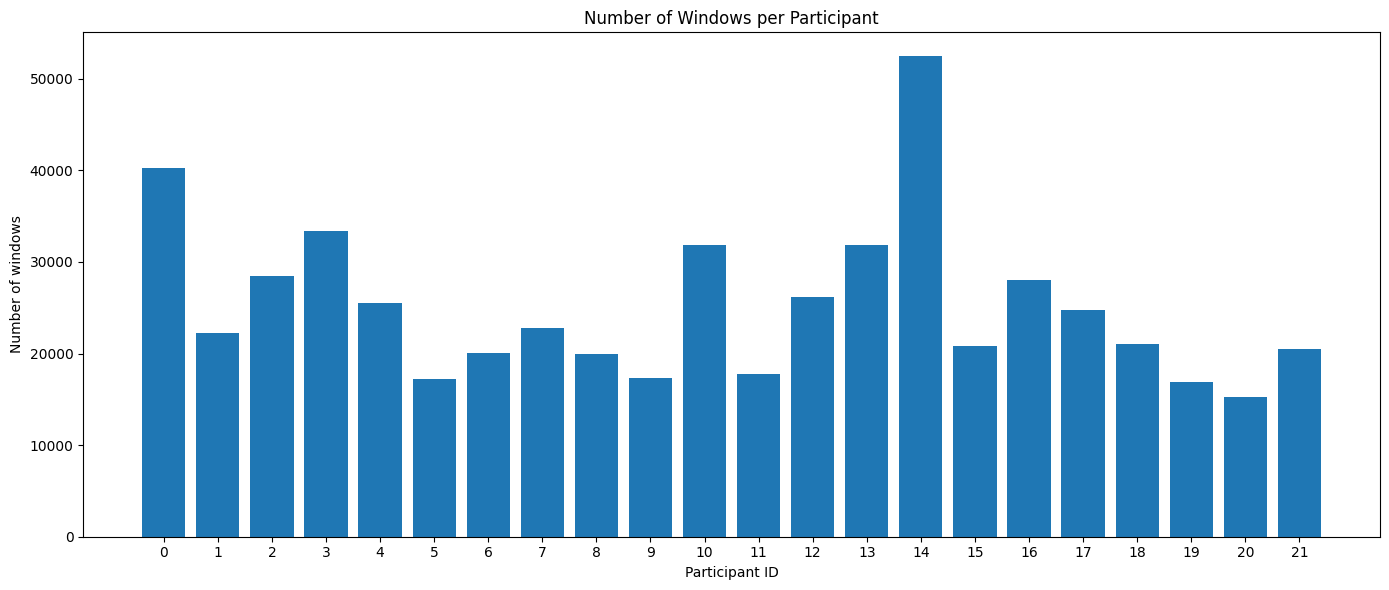

In [15]:
# ============================================================
# EDA — PARTICIPANT DISTRIBUTION
# ============================================================

participant_counts = (
    eda_df["sbj_id"]
    .value_counts()
    .sort_index()
)

print("=" * 70)
print("PARTICIPANT DISTRIBUTION")
print("=" * 70)

display(
    participant_counts
    .rename("samples")
    .to_frame()
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.bar(
    participant_counts.index.astype(str),
    participant_counts.values
)

plt.xlabel("Participant ID")
plt.ylabel("Number of windows")
plt.title(
    "Number of Windows per Participant"
)

plt.tight_layout()

plt.show()

# **| # Experiment                                         | What we changed                                                                                                                     | Why we did it                                                                                                                                                                                         
| **Exp 1 — Basic Inertial CNN**                     | Used a simple **1D CNN** on 3-axis inertial acceleration.                                       | Establish a **baseline**: first see how well acceleration alone can classify the 19 activities.                                                                                                       |
| **Exp 2 — Sensor Location**                        | Added a **learned sensor-location embedding** for right arm, right leg, left leg, and left arm. | The same movement can look different depending on **where the sensor is attached**. We wanted the model to use that information.                                                                      |
| **Exp 3 — Improved CNN Architecture**              | Made the CNN stronger by adding **more convolution blocks**.                                    | A simple CNN may not extract sufficiently rich movement patterns. We tested whether a deeper feature extractor could learn better representations.                                                    |
| **Exp 4 — Multi-Scale Temporal Features**          | Used **different kernel sizes / receptive fields**.                                             | Activities contain patterns at different time scales. Small kernels can capture short movements, while larger receptive fields can capture longer movement patterns.                                  |
| **Exp 5 — Regularization / Training Improvements** | Tested **augmentation, class weighting, dropout, and alternative loss functions**.              | The goal was to improve **generalization**, particularly for difficult/underrepresented activity classes, rather than simply making the network bigger.                                               |


#**Why Experiments 1–5 were not enough**

Experiment What was limited Why we moved to the next experiment 
**Exp 1** — Basic Inertial CNN Simple CNN used only acceleration features. The model had limited information about where the sensor was located and had a relatively basic feature extractor.

**Exp 2** — Sensor Location Added sensor-location information. Location helped provide context, but simply knowing the location does not make the CNN better at learning complex temporal movement patterns.

**Exp 3** — Improved CNN Added more convolution blocks. A deeper CNN can learn richer features, but convolution alone still treats the temporal representation relatively uniformly and may miss patterns at different time scales.

**Exp 4** — Multi-Scale Features Used different receptive fields/kernel sizes. This captures movement at different scales, but it still does not explicitly learn which time steps are most important for a particular activity.

**Exp 5** — Training Improvements Tried augmentation, class weighting, dropout and alternative losses. These can improve generalization, but they don't fundamentally change the model's ability to focus on informative temporal regions.

#**So why Exp 6?**

“Experiments 1 to 5 mainly focused on improving the feature extractor and the training process. However, I noticed an important limitation: a 1-second inertial window contains 50 time steps, and not every time step is equally informative for recognizing an activity. Therefore, in Experiment 6, I introduced Temporal Attention so that the model could learn which parts of the temporal sequence were more important for classification.”

In [24]:
# ============================================================
# CELL 3: LOCATION-AWARE TEMPORAL ATTENTION MODEL
# ============================================================

import torch
import torch.nn as nn


# ============================================================
# Residual ConvBlock
# ============================================================

class ConvBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=5,
            stride=stride,
            padding=2
        )

        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size=5,
            padding=2
        )

        self.bn2 = nn.BatchNorm1d(out_channels)

        if in_channels != out_channels or stride != 1:
            self.shortcut = nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size=1,
                stride=stride
            )
        else:
            self.shortcut = nn.Identity()

        self.relu = nn.ReLU()


    def forward(self, x):

        identity = self.shortcut(x)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        x = x + identity

        x = self.relu(x)

        return x


# ============================================================
# Temporal Attention
# ============================================================

class TemporalAttention(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.attention = nn.Sequential(

            nn.Conv1d(
                channels,
                channels // 2,
                kernel_size=1
            ),

            nn.ReLU(),

            nn.Conv1d(
                channels // 2,
                1,
                kernel_size=1
            )
        )


    def forward(self, x):

        # x shape:
        # (batch, channels, time)

        attention_scores = self.attention(x)

        # Softmax across time
        attention_weights = torch.softmax(
            attention_scores,
            dim=2
        )

        # Weighted temporal features
        x = x * attention_weights

        return x.sum(dim=2)


# ============================================================
# Location-Aware Temporal Attention Model
# ============================================================

class WEARInertialNet(nn.Module):

    def __init__(
        self,
        num_classes=19,
        num_locations=4
    ):

        super().__init__()


        # ----------------------------------------------------
        # CNN feature extractor
        # ----------------------------------------------------

        self.conv1 = nn.Conv1d(
            3,
            32,
            kernel_size=7,
            padding=3
        )

        self.bn1 = nn.BatchNorm1d(32)

        self.relu = nn.ReLU()


        self.block1 = ConvBlock(
            32,
            32
        )

        self.block2 = ConvBlock(
            32,
            64,
            stride=2
        )

        self.block3 = ConvBlock(
            64,
            128,
            stride=2
        )


        # ----------------------------------------------------
        # Temporal attention
        # ----------------------------------------------------

        self.temporal_attention = TemporalAttention(
            128
        )


        # ----------------------------------------------------
        # Sensor location embedding
        # ----------------------------------------------------

        self.location_embedding = nn.Embedding(
            num_locations,
            8
        )


        # ----------------------------------------------------
        # Location-conditioned feature
        # ----------------------------------------------------

        self.location_fc = nn.Sequential(

            nn.Linear(
                8,
                16
            ),

            nn.ReLU()
        )


        # ----------------------------------------------------
        # Final classifier
        # ----------------------------------------------------

        self.fc = nn.Sequential(

            nn.Linear(
                128 + 16,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(
                128,
                num_classes
            )
        )


    # ========================================================
    # Forward
    # ========================================================

    def forward(
        self,
        x,
        location
    ):

        # ----------------------------------------------------
        # CNN
        # ----------------------------------------------------

        x = self.conv1(x)

        x = self.bn1(x)

        x = self.relu(x)


        x = self.block1(x)

        x = self.block2(x)

        x = self.block3(x)


        # ----------------------------------------------------
        # Temporal attention
        # ----------------------------------------------------

        x = self.temporal_attention(x)


        # ----------------------------------------------------
        # Location embedding
        # ----------------------------------------------------

        location = self.location_embedding(
            location
        )

        location = self.location_fc(
            location
        )


        # ----------------------------------------------------
        # Combine movement + location
        # ----------------------------------------------------

        x = torch.cat(
            [
                x,
                location
            ],
            dim=1
        )


        # ----------------------------------------------------
        # Classification
        # ----------------------------------------------------

        return self.fc(x)


# ============================================================
# Create Model
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


model = WEARInertialNet(
    num_classes=len(LABEL_MAP),
    num_locations=4
).to(device)


print(model)

print(
    "\nDevice:",
    device
)

WEARInertialNet(
  (conv1): Conv1d(3, 32, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (block1): ConvBlock(
    (conv1): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Identity()
    (relu): ReLU()
  )
  (block2): ConvBlock(
    (conv1): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Conv1d(32, 64, kernel_size=(1,), stride

#**Experiment 6 — Temporal Attention for Inertial Activity Recognition**

**Goal:**
Improve the basic inertial CNN by allowing the model to learn which parts of the 1-second movement window are most important for identifying an activity.

Instead of treating all 50 time samples equally, a Temporal Attention layer learns to give more importance to useful movement patterns and less importance to uninformative parts.


Inertial Sensor Data

       │
       │  3-axis acceleration
       │
       ▼
       
   CNN Backbone
   
       │
       │  Temporal features
       ▼
       
 Temporal Attention
 
       │
       │  Focus on important time steps
       ▼
       
 Inertial Feature
 
       │
       ├──────────────┐
       │              │
       │       Sensor Location
       │          Embedding
       │              │
       └───────┬──────┘
               ▼
               
            Fusion
            
               │
               ▼
               
          Classifier
          
               │
               ▼
               
          19 Activities

    

In [16]:
# ==========================================
# CELL 4: TRAINING - TEMPORAL ATTENTION
# ==========================================

import random
import os
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score, accuracy_score


# ==========================================
# SETTINGS
# ==========================================

N_FOLDS = 5
BATCH_SIZE = 256
EPOCHS = 20
LEARNING_RATE = 1e-3
SEED = 42

NUM_CLASSES = len(LABEL_MAP)


# ==========================================
# RANDOM SEED
# ==========================================

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)


# ==========================================
# RUN ONE EPOCH
# ==========================================

def run_epoch(
    model,
    loader,
    loss_function,
    optimizer=None
):

    training = optimizer is not None

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0

    predictions = []
    actual = []


    for x, y, location in loader:

        x = x.to(device)
        y = y.to(device)
        location = location.to(device)


        # --------------------------
        # Forward
        # --------------------------

        output = model(
            x,
            location
        )


        # --------------------------
        # Loss
        # --------------------------

        loss = loss_function(
            output,
            y
        )


        # --------------------------
        # Backpropagation
        # --------------------------

        if training:

            optimizer.zero_grad()

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5
            )

            optimizer.step()


        # --------------------------
        # Store loss
        # --------------------------

        total_loss += (
            loss.item() * x.size(0)
        )


        # --------------------------
        # Predictions
        # --------------------------

        predictions.extend(
            output.argmax(1)
            .detach()
            .cpu()
            .numpy()
        )


        actual.extend(
            y.cpu().numpy()
        )


    # ==================================
    # METRICS
    # ==================================

    avg_loss = (
        total_loss /
        len(actual)
    )

    accuracy = accuracy_score(
        actual,
        predictions
    )

    f1 = f1_score(
        actual,
        predictions,
        average="macro"
    )


    return (
        avg_loss,
        accuracy,
        f1
    )


# ==========================================
# TRAIN ONE FOLD
# ==========================================

def train_fold(
    train_samples,
    val_samples,
    fold
):

    print("\n" + "=" * 50)
    print(f"FOLD {fold}")
    print("=" * 50)


    # ==================================
    # NORMALIZATION
    # ==================================

    mean, std = get_normalization(
        train_samples
    )


    train_dataset = WEARDataset(
        train_samples,
        mean,
        std
    )


    val_dataset = WEARDataset(
        val_samples,
        mean,
        std
    )


    # ==================================
    # DATALOADERS
    # ==================================

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )


    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )


    # ==================================
    # CREATE MODEL
    # ==================================

    model = WEARInertialNet(
        num_classes=NUM_CLASSES,
        num_locations=4
    ).to(device)


    # ==================================
    # CLASS WEIGHTS
    # ==================================

    labels = np.array([
        sample["y"]
        for sample in train_samples
    ])


    class_counts = np.bincount(
        labels,
        minlength=NUM_CLASSES
    ).astype(np.float32)


    # Square-root inverse frequency
    class_weights = (
        1.0 /
        np.sqrt(class_counts + 1e-6)
    )


    # Normalize around 1
    class_weights = (
        class_weights /
        class_weights.mean()
    )


    # Prevent extreme weights
    class_weights = np.clip(
        class_weights,
        0.25,
        5.0
    )


    class_weights = torch.tensor(
        class_weights,
        dtype=torch.float32
    ).to(device)


    # ==================================
    # LOSS
    # ==================================

    loss_function = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=0.05
    )


    # ==================================
    # OPTIMIZER
    # ==================================

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-4
    )


    # ==================================
    # LR SCHEDULER
    # ==================================

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS
    )


    # ==================================
    # HISTORY
    # ==================================

    history = {

        "train_loss": [],
        "val_loss": [],

        "train_f1": [],
        "val_f1": [],

        "train_acc": [],
        "val_acc": []
    }


    # ==================================
    # BEST MODEL
    # ==================================

    best_f1 = 0.0
    best_model = None


    # ==================================
    # TRAINING LOOP
    # ==================================

    for epoch in range(EPOCHS):


        # ------------------------------
        # Training
        # ------------------------------

        train_loss, train_acc, train_f1 = run_epoch(
            model,
            train_loader,
            loss_function,
            optimizer
        )


        # ------------------------------
        # Validation
        # ------------------------------

        val_loss, val_acc, val_f1 = run_epoch(
            model,
            val_loader,
            loss_function
        )


        # ------------------------------
        # Scheduler
        # ------------------------------

        scheduler.step()


        # ------------------------------
        # Save history
        # ------------------------------

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        history["train_f1"].append(
            train_f1
        )

        history["val_f1"].append(
            val_f1
        )

        history["train_acc"].append(
            train_acc
        )

        history["val_acc"].append(
            val_acc
        )


        # ------------------------------
        # Print
        # ------------------------------

        print(
            f"Epoch {epoch + 1:02d}/{EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train F1: {train_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val F1: {val_f1:.4f}"
        )


        # ------------------------------
        # Save best model
        # ------------------------------

        if val_f1 > best_f1:

            best_f1 = val_f1

            best_model = {
                key: value.cpu().clone()
                for key, value in model.state_dict().items()
            }


    # ==================================
    # LOAD BEST MODEL
    # ==================================

    if best_model is not None:

        model.load_state_dict(
            best_model
        )


    print(
        f"\nBest Validation F1: "
        f"{best_f1:.4f}"
    )


    return (
        model,
        (mean, std),
        best_f1,
        history
    )


# ==========================================
# 5-FOLD GROUP CROSS VALIDATION
# ==========================================

print(
    "\nPreparing cross-validation..."
)


groups = np.array([
    sample["sbj_id"]
    for sample in samples
])


labels = np.array([
    sample["y"]
    for sample in samples
])


print(
    "Total samples:",
    len(samples)
)


print(
    "Unique participants:",
    len(np.unique(groups))
)


# ==========================================
# GROUP K-FOLD
# ==========================================

gkf = GroupKFold(
    n_splits=N_FOLDS
)


# ==========================================
# STORE RESULTS
# ==========================================

fold_models = []
fold_scores = []
fold_histories = []


# ==========================================
# TRAIN ALL FOLDS
# ==========================================

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(
        samples,
        labels,
        groups
    ),
    start=1
):


    train_samples = [
        samples[i]
        for i in train_idx
    ]


    val_samples = [
        samples[i]
        for i in val_idx
    ]


    print(
        f"\nFold {fold}: "
        f"Train = {len(train_samples)}, "
        f"Validation = {len(val_samples)}"
    )


    # ------------------------------
    # Train fold
    # ------------------------------

    model, normalization, score, history = train_fold(
        train_samples,
        val_samples,
        fold
    )


    # ------------------------------
    # Save model
    # ------------------------------

    model_path = os.path.join(
        OUT_DIR,
        f"attention_model_fold{fold}.pt"
    )


    torch.save(
        model.state_dict(),
        model_path
    )


    print(
        "Saved:",
        model_path
    )


    # ------------------------------
    # Store results
    # ------------------------------

    fold_models.append(
        (
            model,
            normalization
        )
    )


    fold_scores.append(
        score
    )


    fold_histories.append(
        history
    )


# ==========================================
# FINAL RESULTS
# ==========================================

print("\n")

print("=" * 40)
print("TEMPORAL ATTENTION RESULTS")
print("=" * 40)


for fold, score in enumerate(
    fold_scores,
    start=1
):

    print(
        f"Fold {fold}: "
        f"F1 = {score:.4f}"
    )


print("-" * 40)


print(
    f"Mean Macro-F1: "
    f"{np.mean(fold_scores):.4f}"
)


print(
    f"Std Macro-F1: "
    f"{np.std(fold_scores):.4f}"
)


print("=" * 40)


Preparing cross-validation...
Total samples: 554528
Unique participants: 22

Fold 1: Train = 439720, Validation = 114808

FOLD 1
Epoch 01/20 | Train Loss: 1.7206 | Train F1: 0.4674 | Val Loss: 1.7753 | Val F1: 0.4638
Epoch 02/20 | Train Loss: 1.4713 | Train F1: 0.5620 | Val Loss: 1.6947 | Val F1: 0.4892
Epoch 03/20 | Train Loss: 1.3781 | Train F1: 0.6011 | Val Loss: 1.6375 | Val F1: 0.5209
Epoch 04/20 | Train Loss: 1.3138 | Train F1: 0.6291 | Val Loss: 1.6223 | Val F1: 0.5363
Epoch 05/20 | Train Loss: 1.2690 | Train F1: 0.6490 | Val Loss: 1.6058 | Val F1: 0.5407
Epoch 06/20 | Train Loss: 1.2350 | Train F1: 0.6638 | Val Loss: 1.5918 | Val F1: 0.5539
Epoch 07/20 | Train Loss: 1.2054 | Train F1: 0.6760 | Val Loss: 1.5941 | Val F1: 0.5507
Epoch 08/20 | Train Loss: 1.1805 | Train F1: 0.6878 | Val Loss: 1.5892 | Val F1: 0.5621
Epoch 09/20 | Train Loss: 1.1570 | Train F1: 0.6968 | Val Loss: 1.5692 | Val F1: 0.5673
Epoch 10/20 | Train Loss: 1.1394 | Train F1: 0.7046 | Val Loss: 1.5727 | Val F

In [17]:
# ============================================================
# OOF PREDICTIONS - TEMPORAL ATTENTION MODEL
# ============================================================

import os
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report


print("=" * 60)
print("OUT-OF-FOLD PREDICTIONS")
print("=" * 60)


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

N_FOLDS = 5
BATCH_SIZE = 256
NUM_CLASSES = len(LABEL_MAP)


# ------------------------------------------------------------
# Prepare arrays
# ------------------------------------------------------------

groups = np.array([
    sample["sbj_id"]
    for sample in samples
])

labels = np.array([
    sample["y"]
    for sample in samples
])


# ------------------------------------------------------------
# Create OOF prediction arrays
# ------------------------------------------------------------

oof_predictions = np.full(
    len(samples),
    -1,
    dtype=np.int64
)

oof_true = np.array(labels, dtype=np.int64)


# ------------------------------------------------------------
# GroupKFold
# ------------------------------------------------------------

gkf = GroupKFold(
    n_splits=N_FOLDS
)


# ------------------------------------------------------------
# Evaluate each fold
# ------------------------------------------------------------

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(samples, labels, groups),
    start=1
):

    print(f"\nEvaluating Fold {fold}...")


    # --------------------------------------------------------
    # Recreate train/validation samples
    # --------------------------------------------------------

    train_samples = [
        samples[i]
        for i in train_idx
    ]

    val_samples = [
        samples[i]
        for i in val_idx
    ]


    # --------------------------------------------------------
    # Calculate normalization using TRAINING data only
    # --------------------------------------------------------

    mean, std = get_normalization(
        train_samples
    )


    # --------------------------------------------------------
    # Validation dataset
    # --------------------------------------------------------

    val_dataset = WEARDataset(
        val_samples,
        mean,
        std
    )


    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )


    # --------------------------------------------------------
    # Create same model architecture
    # --------------------------------------------------------

    model = WEARInertialNet(
        num_classes=NUM_CLASSES,
        num_locations=4
    ).to(device)


    # --------------------------------------------------------
    # Load trained fold model
    # --------------------------------------------------------

    model_path = os.path.join(
        OUT_DIR,
        f"attention_model_fold{fold}.pt"
    )


    if not os.path.exists(model_path):

        raise FileNotFoundError(
            f"\nModel file not found:\n{model_path}\n"
            f"\nCheck that the trained attention models "
            f"are saved with names:\n"
            f"attention_model_fold1.pt ... "
            f"attention_model_fold5.pt"
        )


    checkpoint = torch.load(
        model_path,
        map_location=device
    )


    model.load_state_dict(
        checkpoint
    )


    model.eval()


    # --------------------------------------------------------
    # Predict validation fold
    # --------------------------------------------------------

    fold_predictions = []


    with torch.no_grad():

        for x, y, location in val_loader:

            x = x.to(device)
            location = location.to(device)


            output = model(
                x,
                location
            )


            predictions = output.argmax(
                dim=1
            )


            fold_predictions.extend(
                predictions.cpu().numpy()
            )


    fold_predictions = np.array(
        fold_predictions,
        dtype=np.int64
    )


    # --------------------------------------------------------
    # Store predictions in original sample positions
    # --------------------------------------------------------

    if len(fold_predictions) != len(val_idx):

        raise RuntimeError(
            f"Fold {fold} prediction size mismatch: "
            f"{len(fold_predictions)} predictions "
            f"for {len(val_idx)} validation samples."
        )


    oof_predictions[val_idx] = fold_predictions


    print(
        f"Fold {fold} complete | "
        f"Validation samples: {len(val_idx)}"
    )


# ============================================================
# Check that EVERY sample received a prediction
# ============================================================

missing_predictions = np.sum(
    oof_predictions == -1
)


print("\n")
print("=" * 60)
print("OOF PREDICTION CHECK")
print("=" * 60)

print(
    "Total samples:",
    len(samples)
)

print(
    "Predictions generated:",
    np.sum(oof_predictions != -1)
)

print(
    "Missing predictions:",
    missing_predictions
)


# IMPORTANT:
# This should print True

all_predictions_present = (
    missing_predictions == 0
)

print(
    "All samples have OOF predictions:",
    all_predictions_present
)


# ============================================================
# Stop if something went wrong
# ============================================================

if not all_predictions_present:

    raise RuntimeError(
        f"\n{missing_predictions} samples do not have "
        f"OOF predictions."
    )


# ============================================================
# OOF RESULTS
# ============================================================

oof_accuracy = accuracy_score(
    oof_true,
    oof_predictions
)

oof_macro_f1 = f1_score(
    oof_true,
    oof_predictions,
    average="macro"
)


print("\n")
print("=" * 60)
print("OOF RESULTS")
print("=" * 60)

print(
    f"OOF Accuracy : {oof_accuracy:.4f}"
)

print(
    f"OOF Macro-F1 : {oof_macro_f1:.4f}"
)

print("=" * 60)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

class_names = [
    name
    for name, class_id in sorted(
        LABEL_MAP.items(),
        key=lambda item: item[1]
    )
]


print("\n")
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)


print(
    classification_report(
        oof_true,
        oof_predictions,
        labels=list(range(NUM_CLASSES)),
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

OUT-OF-FOLD PREDICTIONS

Evaluating Fold 1...
Fold 1 complete | Validation samples: 114808

Evaluating Fold 2...
Fold 2 complete | Validation samples: 103948

Evaluating Fold 3...
Fold 3 complete | Validation samples: 116980

Evaluating Fold 4...
Fold 4 complete | Validation samples: 102128

Evaluating Fold 5...
Fold 5 complete | Validation samples: 116664


OOF PREDICTION CHECK
Total samples: 554528
Predictions generated: 554528
Missing predictions: 0
All samples have OOF predictions: True


OOF RESULTS
OOF Accuracy : 0.6277
OOF Macro-F1 : 0.6012


CLASSIFICATION REPORT
                              precision    recall  f1-score   support

                        null     0.7658    0.6266    0.6893    220456
                     jogging     0.7119    0.7674    0.7386     20024
     jogging (rotating arms)     0.6244    0.6171    0.6207     17536
          jogging (skipping)     0.8320    0.8292    0.8306     18212
         jogging (sidesteps)     0.7998    0.8534    0.8258     19732
 

In [19]:
# Check which OOF-related variables currently exist

print("OOF-related variables found:")

for name in dir():
    if "oof" in name.lower():
        try:
            value = globals()[name]
            if hasattr(value, "shape"):
                print(name, "->", value.shape)
            else:
                print(name, "->", type(value))
        except:
            pass

OOF-related variables found:
oof_accuracy -> <class 'float'>
oof_macro_f1 -> <class 'float'>
oof_predictions -> (554528,)
oof_true -> (554528,)


In [20]:


# Folder for Exp6 results
EXP6_DIR = "/kaggle/working/exp6_temporal_attention"
os.makedirs(EXP6_DIR, exist_ok=True)

# 1. Save OOF predictions
np.save(
    os.path.join(EXP6_DIR, "oof_predictions.npy"),
    oof_predictions
)

# 2. Save true labels
np.save(
    os.path.join(EXP6_DIR, "oof_targets.npy"),
    oof_true
)

# 3. Save overall metrics
results = pd.DataFrame({
    "metric": [
        "OOF Macro-F1",
        "OOF Accuracy"
    ],
    "value": [
        oof_macro_f1,
        oof_accuracy
    ]
})

results.to_csv(
    os.path.join(EXP6_DIR, "results.csv"),
    index=False
)

# Check
print("✅ Exp6 results saved successfully!")
print()
print("Files:")
for file in os.listdir(EXP6_DIR):
    print(" -", file)

print()
print("OOF predictions shape:", oof_predictions.shape)
print("OOF true shape:", oof_true.shape)
print("OOF Macro-F1:", oof_macro_f1)
print("OOF Accuracy:", oof_accuracy)

✅ Exp6 results saved successfully!

Files:
 - results.csv
 - oof_predictions.npy
 - oof_targets.npy

OOF predictions shape: (554528,)
OOF true shape: (554528,)
OOF Macro-F1: 0.6012395869539117
OOF Accuracy: 0.6277050031738703


In [22]:
# ============================================================
# SAVE EXP6 - TEMPORAL ATTENTION RESULTS
# ============================================================

# ------------------------------------------------------------
# 1. Create Exp6 output folder
# ------------------------------------------------------------

EXP6_DIR = "/kaggle/working/exp6_temporal_attention"

os.makedirs(EXP6_DIR, exist_ok=True)

# ------------------------------------------------------------
# 2. Save OOF predictions
# ------------------------------------------------------------

np.save(
    os.path.join(EXP6_DIR, "oof_predictions.npy"),
    oof_predictions
)

# ------------------------------------------------------------
# 3. Save OOF true labels
# ------------------------------------------------------------

np.save(
    os.path.join(EXP6_DIR, "oof_targets.npy"),
    oof_true
)

# ------------------------------------------------------------
# 4. Save overall metrics
# ------------------------------------------------------------

results = pd.DataFrame({
    "metric": [
        "OOF Macro-F1",
        "OOF Accuracy"
    ],
    "value": [
        float(oof_macro_f1),
        float(oof_accuracy)
    ]
})

results.to_csv(
    os.path.join(EXP6_DIR, "results.csv"),
    index=False
)

# ------------------------------------------------------------
# 5. Save fold scores if available
# ------------------------------------------------------------

if "fold_scores" in globals():

    fold_results = pd.DataFrame({
        "fold": np.arange(1, len(fold_scores) + 1),
        "macro_f1": fold_scores
    })

    fold_results.to_csv(
        os.path.join(EXP6_DIR, "fold_scores.csv"),
        index=False
    )

    print("Fold scores saved.")

else:
    print("fold_scores variable not found - skipping fold scores.")

# ------------------------------------------------------------
# 6. Verification
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("EXP6 RESULTS SAVED SUCCESSFULLY")
print("=" * 60)

print("\nOutput folder:")
print(EXP6_DIR)

print("\nFiles saved:")

for filename in sorted(os.listdir(EXP6_DIR)):
    filepath = os.path.join(EXP6_DIR, filename)
    size_mb = os.path.getsize(filepath) / (1024 * 1024)
    print(f"  ✓ {filename:<25} {size_mb:.2f} MB")

print("\nData verification:")
print("  OOF predictions :", oof_predictions.shape)
print("  OOF true labels :", oof_true.shape)
print("  OOF Macro-F1    :", round(float(oof_macro_f1), 4))
print("  OOF Accuracy    :", round(float(oof_accuracy), 4))

print("\n" + "=" * 60)

Fold scores saved.

EXP6 RESULTS SAVED SUCCESSFULLY

Output folder:
/kaggle/working/exp6_temporal_attention

Files saved:
  ✓ fold_scores.csv           0.00 MB
  ✓ oof_predictions.npy       4.23 MB
  ✓ oof_targets.npy           4.23 MB
  ✓ results.csv               0.00 MB

Data verification:
  OOF predictions : (554528,)
  OOF true labels : (554528,)
  OOF Macro-F1    : 0.6012
  OOF Accuracy    : 0.6277



In [23]:
# ============================================================
# SENSOR-LOCATION ANALYSIS OF OOF PREDICTIONS
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix


print("=" * 70)
print("OOF PERFORMANCE BY SENSOR LOCATION")
print("=" * 70)


# ------------------------------------------------------------
# Sensor location for every sample
# ------------------------------------------------------------

locations = np.array([
    sample["location"]
    for sample in samples
])


# ------------------------------------------------------------
# Check locations
# ------------------------------------------------------------

print("\nSensor locations:")
print(np.unique(locations, return_counts=True))


# ============================================================
# 1. Overall performance for each sensor location
# ============================================================

print("\n")
print("=" * 70)
print("PERFORMANCE BY SENSOR LOCATION")
print("=" * 70)


location_results = []


for location in LOCATIONS:

    mask = locations == location

    y_true = oof_true[mask]
    y_pred = oof_predictions[mask]

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    location_results.append({
        "location": location,
        "samples": int(mask.sum()),
        "accuracy": accuracy,
        "macro_f1": macro_f1
    })


location_results_df = pd.DataFrame(
    location_results
)


print(
    location_results_df.to_string(
        index=False,
        formatters={
            "accuracy": "{:.4f}".format,
            "macro_f1": "{:.4f}".format
        }
    )
)


# ============================================================
# 2. Per-class F1 for EACH sensor location
# ============================================================

print("\n")
print("=" * 70)
print("PER-CLASS F1 BY SENSOR LOCATION")
print("=" * 70)


class_names = [
    name
    for name, class_id in sorted(
        LABEL_MAP.items(),
        key=lambda item: item[1]
    )
]


for location in LOCATIONS:

    print("\n")
    print("-" * 70)
    print(f"SENSOR LOCATION: {location}")
    print("-" * 70)

    mask = locations == location

    y_true = oof_true[mask]
    y_pred = oof_predictions[mask]

    f1_per_class = f1_score(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        average=None,
        zero_division=0
    )

    for class_id, f1 in enumerate(f1_per_class):

        print(
            f"{class_id:02d} | "
            f"{class_names[class_id]:35s} | "
            f"F1 = {f1:.4f}"
        )


# ============================================================
# 3. Important confusion analysis
# ============================================================

IMPORTANT_CLASSES = [
    "stretching (shoulders)",
    "stretching (triceps)",
    "stretching (lunging)",
    "stretching (hamstrings)",
    "jogging (rotating arms)",
    "jogging",
    "lunges",
    "lunges (complex)",
    "bench-dips",
    "burpees"
]


print("\n")
print("=" * 70)
print("IMPORTANT CLASS PERFORMANCE BY SENSOR LOCATION")
print("=" * 70)


important_ids = [
    LABEL_MAP[name]
    for name in IMPORTANT_CLASSES
]


rows = []


for location in LOCATIONS:

    mask = locations == location

    y_true = oof_true[mask]
    y_pred = oof_predictions[mask]

    f1_per_class = f1_score(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        average=None,
        zero_division=0
    )

    for class_name, class_id in zip(
        IMPORTANT_CLASSES,
        important_ids
    ):

        rows.append({
            "location": location,
            "class": class_name,
            "f1": f1_per_class[class_id]
        })


important_df = pd.DataFrame(rows)


print(
    important_df.to_string(
        index=False,
        formatters={
            "f1": "{:.4f}".format
        }
    )
)


# ============================================================
# 4. Check specific confusion:
#    CLASS -> PREDICTED CLASS by location
# ============================================================

CONFUSION_PAIRS = [
    ("stretching (shoulders)", "null"),
    ("stretching (triceps)", "null"),
    ("stretching (lunging)", "null"),
    ("jogging (rotating arms)", "jogging"),
    ("lunges", "null"),
    ("bench-dips", "null"),
    ("burpees", "null")
]


print("\n")
print("=" * 70)
print("IMPORTANT CONFUSIONS BY SENSOR LOCATION")
print("=" * 70)


for true_name, pred_name in CONFUSION_PAIRS:

    true_id = LABEL_MAP[true_name]
    pred_id = LABEL_MAP[pred_name]

    print("\n")
    print(
        f"{true_name} -> {pred_name}"
    )

    for location in LOCATIONS:

        mask = (
            (locations == location) &
            (oof_true == true_id)
        )

        total_true_class = mask.sum()

        if total_true_class == 0:
            percentage = 0.0
        else:

            confusion_count = np.sum(
                oof_predictions[mask] == pred_id
            )

            percentage = (
                confusion_count /
                total_true_class
            ) * 100

        print(
            f"  {location:12s} : "
            f"{percentage:6.2f}%"
        )


print("\n")
print("=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)

OOF PERFORMANCE BY SENSOR LOCATION

Sensor locations:
(array(['left_arm', 'left_leg', 'right_arm', 'right_leg'], dtype='<U9'), array([138632, 138632, 138632, 138632]))


PERFORMANCE BY SENSOR LOCATION
 location  samples accuracy macro_f1
right_arm   138632   0.6492   0.6195
right_leg   138632   0.6039   0.5845
 left_leg   138632   0.5893   0.5702
 left_arm   138632   0.6582   0.6260


PER-CLASS F1 BY SENSOR LOCATION


----------------------------------------------------------------------
SENSOR LOCATION: right_arm
----------------------------------------------------------------------
00 | null                                | F1 = 0.7135
01 | jogging                             | F1 = 0.8527
02 | jogging (rotating arms)             | F1 = 0.7227
03 | jogging (skipping)                  | F1 = 0.7473
04 | jogging (sidesteps)                 | F1 = 0.7741
05 | jogging (butt-kicks)                | F1 = 0.7533
06 | stretching (triceps)                | F1 = 0.6809
07 | stretching (lunging

#**What changed from the earlier experiments?**

The important improvement was Temporal Attention.

The model learns something like:

“For this activity, these particular moments in the 1-second window are more informative.”

This is useful because activities such as jogging, push-ups, stretching, etc. contain different temporal movement patterns.

Architecture details we recorded
Inertial CNN backbone
Temporal Attention: 128 → 64 → 1 using Conv1D
Sensor-location embedding: 4 → 8
Fusion layer: 136 → 128
Final classifier: 128 → 19
Result

Mean 5-fold CV Macro-F1: 0.5973

OOF Macro-F1: 0.5998

OOF Accuracy: 0.6251

In [ ]:
For next experiment go to https://www.kaggle.com/code/swathiha/notebook88ca6e58c9/edit